# Tertiary muons from neutrino interactions in rock

This notebook estimates the muon beam produced when the forward neutrino flux interacts in the rock upstream of the 5 km detector.  Charged-current DIS on nucleons is the dominant source:

- downstream detector: $\bar\nu_\mu N \to \mu^+ X$;
- upstream detector: $\nu_\mu N \to \mu^- X$.

The upstream side also has inverse muon decay on rock electrons,
$\nu_\mu e^- \to \mu^-\nu_e$ and $\bar\nu_e e^- \to \mu^-\bar\nu_\mu$.
These electron-target channels are much smaller in total cross section than DIS, but their muons are hard and very collinear.

The workflow is:

1. select neutrino rays crossing a halo around the detector face;
2. sample a rock interaction point and the outgoing muon kinematics;
3. propagate each muon through rock with `nupyprop` energy loss plus multiple scattering;
4. count the muons reaching the face plane and the detector radius;
5. compare spectra, spatial profiles, production depths, and arrival times.

All lengths in the code are in cm, energies are in GeV, and rates are normalized to one year of operation unless a plot explicitly divides by bunch crossings.

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

import mint
mint.xsecs.use_backend("ct18")
from mint import const
from mint import detector_tools as dt
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

import muon_beam as mb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Beam simulation and face-plane rays

The detector front face is 5 km from the IP, with a 2 m radius and a 10 m air gap between the rock and the detector.  The neutrino ray selection uses a 6 m halo rather than only the detector radius, because muons produced off axis can scatter or be emitted into the detector acceptance.

The bunch-crossing normalization is the number of bunch passages during the live year, computed from the ring duty factor, circumference, and bunch multiplicity.

In [28]:
RUN_VALIDATION = True

ring, sims, injections_per_year = mint.examples.both_beams(
    flavors=("numubar", "numu", "nuebar"))
sim, sim_numu, sim_nueb = sims["numubar"], sims["numu"], sims["nuebar"]

crossings_per_year = (ring.duty_factor * const.s_in_year
                      * const.c_LIGHT / ring.total_circumference * ring.bunch_multiplicity)
print(f"bunch crossings / year: {crossings_per_year:.3e}")

det = mint.detectors.load("benchmark_5km")
DIST, DET_R, GAP = det.dist, det.radius, det.gap
R_SEL = 600.0
L_PROP = 5e5
rock = det.rock

def face_rays(s, sign=+1, r_sel=R_SEL):
    """Neutrino rays through the face-plane halo, weighted to one live year."""
    return det.face_rays(s, sign=sign, r_sel=r_sel, E_min=15.0,
                         exposure=injections_per_year)

rays_p = face_rays(sim)
rays_m = face_rays(sim_numu, sign=-1)
rays_eb = face_rays(sim_nueb, sign=-1)

for lab, r_ in [("numubar (mu+ beam)", rays_p), ("numu (mu- beam)", rays_m),
                ("nuebar (mu- beam)", rays_eb)]:
    print(f"{lab}: {r_[1].sum():.3e} nu/yr within r < 6 m, {r_[0].size} MC rays")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


bunch crossings / year: 3.011e+11
numubar (mu+ beam): 2.830e+18 nu/yr within r < 6 m, 104411 MC rays
numu (mu- beam): 2.803e+18 nu/yr within r < 6 m, 103674 MC rays
nuebar (mu- beam): 2.802e+18 nu/yr within r < 6 m, 103552 MC rays


## 2. Muon-production cross sections and kinematics

The left panel compares the total muon-production cross sections used by the simulation.  DIS CC is per nucleon and comes from `mint.xsecs.sigma_CC`; IMD is per electron and comes from the analytic inverse-lepton-decay cross section.  The notebook selects the CT18 backend so the DIS totals and the event-level LO sampler use the same PDF family.

The right panel checks the sampled DIS $d\sigma/dE_\mu$ shape at $E_\nu=2$ TeV.  For CC DIS the module samples $(x,y)$ and sets $E_\mu=(1-y)E_\nu$.  For IMD the plotted curves are the analytic $y$ distributions: flat for $\nu_\mu e^-$ and proportional to $(1-y)^2$ for $\bar\nu_e e^-$.

numu: <y> = 0.463
numubar: <y> = 0.354


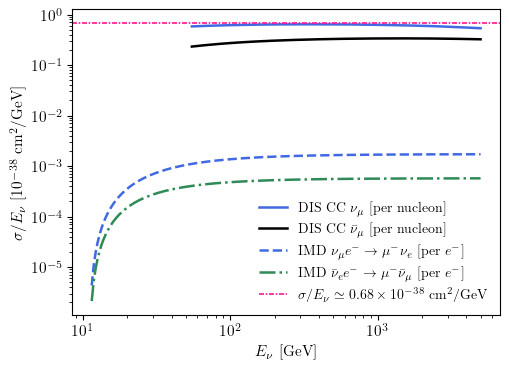

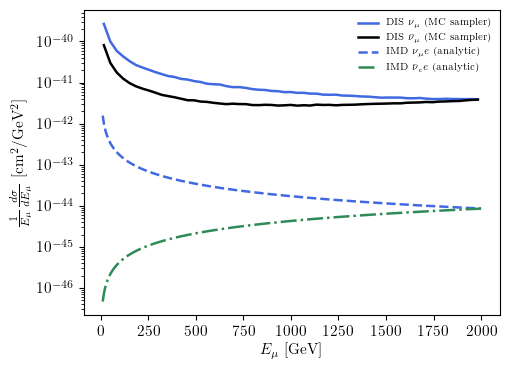

In [29]:
Eg_dis = np.geomspace(55, 5e3, 160)
Eg_imd = np.geomspace(11.5, 5e3, 200)

# --- Figure 1: total cross sections ---
fig1, ax1 = plt.subplots(figsize=(5.2, 3.8))

ax1.plot(Eg_dis, mb.sigma_cc(Eg_dis, "numu") / Eg_dis / 1e-38, color="royalblue", lw=1.8,
         label=r"DIS CC $\nu_\mu$ [per nucleon]")
ax1.plot(Eg_dis, mb.sigma_cc(Eg_dis, "numubar") / Eg_dis / 1e-38, color="black", lw=1.8,
         label=r"DIS CC $\bar\nu_\mu$ [per nucleon]")
ax1.plot(Eg_imd, mb.sigma_imd(Eg_imd, "numu") / Eg_imd / 1e-38, color="royalblue", lw=1.8, ls="--",
         label=r"IMD $\nu_\mu e^- \to \mu^- \nu_e$ [per $e^-$]")
ax1.plot(Eg_imd, mb.sigma_imd(Eg_imd, "nuebar") / Eg_imd / 1e-38, color="seagreen", lw=1.8, ls="-.",
         label=r"IMD $\bar\nu_e e^- \to \mu^- \bar\nu_\mu$ [per $e^-$]")

ax1.axhline(0.677, color="deeppink", lw=1.2, ls=(0, (3, 1, 1, 1)),
            label=r"$\sigma/E_\nu \simeq 0.68 \times 10^{-38}$ cm$^2$/GeV")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$E_\nu$ [GeV]")
ax1.set_ylabel(r"$\sigma/E_\nu$ [$10^{-38}$ cm$^2$/GeV]")
ax1.legend(frameon=False, fontsize=10)

fig1.tight_layout()
fig1.savefig("plots/muon_beam_xsec_totals.pdf", bbox_inches="tight", dpi=300)

# --- Figure 2: differential spectra at E0 ---
E0 = 2000.0
rngv = np.random.default_rng(5)
Emu_edges = np.linspace(0, E0, 60)
Emu_c = 0.5 * (Emu_edges[:-1] + Emu_edges[1:])
dEmu = np.diff(Emu_edges)

fig2, ax2 = plt.subplots(figsize=(5.2, 3.8))

for lab, c, name in [("numu", "royalblue", r"DIS $\nu_\mu$ (MC sampler)"),
                     ("numubar", "black", r"DIS $\bar\nu_\mu$ (MC sampler)")]:
    x_, y_ = mb.sample_cc_xy(np.full(300_000, E0), lab, rngv)
    h, _ = np.histogram((1 - y_) * E0, bins=Emu_edges)
    ax2.plot(Emu_c, h / h.sum() / dEmu * mb.sigma_cc(E0, lab) / Emu_c, color=c, lw=1.8,
             label=name)
    print(f"{lab}: <y> = {y_.mean():.3f}")

s0 = mb.M_E**2 + 2 * mb.M_E * E0
ymax0 = 1 - mb.M_MU**2 / s0
Emu_g = np.linspace(E0 * (1 - ymax0), E0, 300)
y_g = 1 - Emu_g / E0

ax2.plot(Emu_g, np.full_like(Emu_g, mb.sigma_imd(E0, "numu") / (E0 * ymax0)) / Emu_g,
         color="royalblue", lw=1.8, ls="--", label=r"IMD $\nu_\mu e$ (analytic)")
ax2.plot(Emu_g, mb.sigma_imd(E0, "nuebar") * 3 * (1 - y_g) ** 2
         / (E0 * (1 - (1 - ymax0) ** 3)) / Emu_g,
         color="seagreen", lw=1.8, ls="-.", label=r"IMD $\bar\nu_e e$ (analytic)")

ax2.set_yscale("log")
ax2.set_xlabel(r"$E_\mu$ [GeV]")
ax2.set_ylabel(r"$\frac{1}{E_\mu}\frac{d\sigma}{dE_\mu}$ [cm$^2$/GeV$^2$]")
ax2.legend(frameon=False, fontsize=7)

fig2.tight_layout()
fig2.savefig("plots/muon_beam_xsec_differential.pdf", bbox_inches="tight", dpi=300)

## 3. Muon propagation validation

This optional section records single-muon trajectories in standard rock.  It is skipped by default because it propagates thousands of muons.

The validation compares `nupyprop` stochastic energy loss against the continuous-slowing-down estimate.  The survivor median is not expected to follow the continuous curve at large depth, because conditioning on surviving muons selects particles that fluctuated to lose less energy.  The unbiased comparison is the ensemble mean with stopped muons counted at zero energy.

The same runs are also used for a range-straggling survival plot and for the accumulated multiple-scattering angle.

In [30]:
if RUN_VALIDATION:
    X_MAX = L_PROP * mb.RHO_ROCK
    rngt = np.random.default_rng(21)
    N_TRAJ = 1000
    Xg = np.linspace(0.0, X_MAX, 240)
    KM = mb.RHO_ROCK * 1e5

    E_VAL = [1000.0, 3000.0, 5000.0]
    VAL_COLORS = {1000.0: "steelblue", 3000.0: "green", 5000.0: "firebrick"}

    trajs = {}
    for E0t in E_VAL:
        Es, ths = [], []
        for _ in range(N_TRAJ):
            *_, tr = mb.propagate_muon(E0t, X_MAX, rngt, record=True)
            tr = np.asarray(tr)
            xs, es, ts = tr[:, 0], tr[:, 1], tr[:, 2]
            dead = es[-1] <= mb.E_MIN
            Ei = np.interp(Xg, xs, es)
            ti = np.interp(Xg, xs, ts)
            if dead:
                Ei[Xg > xs[-1]] = np.nan
                ti[Xg > xs[-1]] = np.nan
            Es.append(Ei)
            ths.append(ti)
        trajs[E0t] = (np.array(Es), np.array(ths))
    print({k: f"{np.isfinite(v[0][:, -1]).mean():.1%} survive 2.5 km" for k, v in trajs.items()})

    X_SURV = 4e5 * mb.RHO_ROCK
    N_SURV = 30_000
    death_X = {}
    for E0t in E_VAL:
        dx_ = np.empty(N_SURV)
        for i in range(N_SURV):
            res = mb.propagate_muon(E0t, X_SURV, rngt, record=True)
            dx_[i] = res[5][-1][0] if res[0] <= mb.E_MIN else np.inf
        death_X[E0t] = dx_
        print(f"{E0t/1e3:.0f} TeV: {np.isfinite(dx_).mean():.2%} die within 4 km of rock")
else:
    print('Sec. 3 validation skipped (RUN_SLOW_VALIDATION = False)')

{1000.0: '0.3% survive 2.5 km', 3000.0: '0.3% survive 2.5 km', 5000.0: '0.5% survive 2.5 km'}
1 TeV: 100.00% die within 4 km of rock
3 TeV: 100.00% die within 4 km of rock
5 TeV: 100.00% die within 4 km of rock


E0 = 1000 GeV at 0.25 R_CSDA: MC mean   621.1 vs continuous   622.3 GeV  (-0.2%)
E0 = 1000 GeV at 0.50 R_CSDA: MC mean   354.4 vs continuous   358.3 GeV  (-1.1%)
E0 = 1000 GeV at 0.75 R_CSDA: MC mean   162.2 vs continuous   154.1 GeV  (+5.3%)
E0 = 3000 GeV at 0.25 R_CSDA: MC mean  1633.8 vs continuous  1609.0 GeV  (+1.5%)
E0 = 3000 GeV at 0.50 R_CSDA: MC mean   821.2 vs continuous   802.2 GeV  (+2.4%)
E0 = 3000 GeV at 0.75 R_CSDA: MC mean   346.0 vs continuous   300.1 GeV  (+15.3%)
E0 = 5000 GeV at 0.25 R_CSDA: MC mean  2537.2 vs continuous  2501.7 GeV  (+1.4%)
E0 = 5000 GeV at 0.50 R_CSDA: MC mean  1169.4 vs continuous  1143.2 GeV  (+2.3%)
E0 = 5000 GeV at 0.75 R_CSDA: MC mean   441.4 vs continuous   396.6 GeV  (+11.3%)


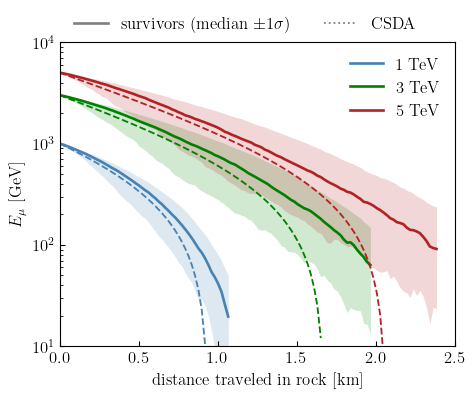

In [72]:
if RUN_VALIDATION:
    import warnings
    from matplotlib.lines import Line2D

    fig, ax = pt.std_fig(figsize=(5, 4))
    for E0t in E_VAL:
        c = VAL_COLORS[E0t]
        Es, _ = trajs[E0t]
        frac = np.isfinite(Es).mean(axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            med = np.nanmedian(Es, axis=0)
            lo = np.nanpercentile(Es, 16, axis=0)
            hi = np.nanpercentile(Es, 84, axis=0)
        mean_all = np.nan_to_num(Es, nan=0.0).mean(axis=0)
        bad = frac < 0.2
        med[bad], lo[bad], hi[bad] = np.nan, np.nan, np.nan
        ax.fill_between(Xg / KM, np.clip(lo, 1.0, None), hi, color=c, alpha=0.18, lw=0)
        ax.plot(Xg / KM, med, color=c, lw=1.9)
        # ax.plot(Xg / KM, np.where(mean_all > 1, mean_all, np.nan), color=c, lw=1.6, ls="--")
        prof = mb.continuous_E_profile(E0t, Xg)
        ax.plot(Xg / KM, np.where(prof > mb.E_MIN, prof, np.nan), color=c, lw=1.3, ls="--")

        X_csda = mb.continuous_range(E0t)
        for fr_ in (0.25, 0.5, 0.75):
            i = np.searchsorted(Xg, fr_ * X_csda)
            print(f"E0 = {E0t:4.0f} GeV at {fr_:.2f} R_CSDA: MC mean {mean_all[i]:7.1f} "
                  f"vs continuous {prof[i]:7.1f} GeV  ({mean_all[i]/prof[i]-1:+.1%})")

    color_handles = [Line2D([], [], color=VAL_COLORS[e], lw=1.9, label=f"{e/1e3:.0f} TeV")
                     for e in E_VAL]
    style_handles = [
        Line2D([], [], color="gray", lw=1.9, label=r"survivors (median $\pm1\sigma$)"),
        # Line2D([], [], color="gray", lw=1.6, ls="--", label="all mean"),
        Line2D([], [], color="gray", lw=1.3, ls=":", label="CSDA"),
    ]
    leg1 = ax.legend(handles=color_handles, frameon=False, fontsize=12, loc="upper right")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, frameon=False, fontsize=12, loc=(0.02, 1.01), ncol=2)
    ax.tick_params(axis="both", which="both", labelsize=12, direction="in")
    ax.set_yscale("log")
    ax.set_ylim(10, 1e4)
    ax.set_xlim(0, 2.5)
    ax.set_xlabel("distance traveled in rock [km]", fontsize=12)
    ax.set_ylabel(r"$E_\mu$ [GeV]", fontsize=12)
    fig.savefig("plots/muon_beam_eloss_validation.pdf", bbox_inches="tight", dpi=300)
else:
    print('Sec. 3 validation skipped (RUN_SLOW_VALIDATION = False)')


1 TeV: R_CSDA = 0.94 km, survival there = 59.0%, median stopping depth = 0.98 km
3 TeV: R_CSDA = 1.68 km, survival there = 48.9%, median stopping depth = 1.66 km
5 TeV: R_CSDA = 2.07 km, survival there = 44.6%, median stopping depth = 2.00 km


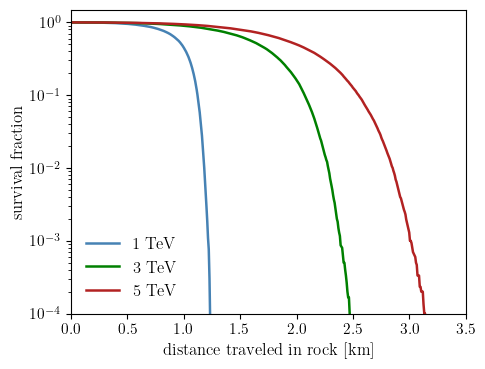

In [38]:
if RUN_VALIDATION:
    fig, ax = pt.std_fig(figsize=(5, 4))
    s_grid = np.linspace(0.0, 4.0, 600)
    for E0t in E_VAL:
        c = VAL_COLORS[E0t]
        dkm = np.sort(death_X[E0t]) / KM
        surv = 1.0 - np.searchsorted(dkm, s_grid, side="right") / dkm.size
        ax.plot(s_grid, np.where(surv > 0, surv, np.nan), color=c, lw=1.8,
                label=f"{E0t/1e3:.0f} TeV")
        X_csda = mb.continuous_range(E0t)
        print(f"{E0t/1e3:.0f} TeV: R_CSDA = {X_csda/KM:.2f} km, survival there = "
              f"{(death_X[E0t] > X_csda).mean():.1%}, median stopping depth = "
              f"{np.median(death_X[E0t])/KM:.2f} km")
    
    ax.set_yscale("log")
    ax.set_xlim(0, 3.5)
    ax.set_ylim(1e-4, 1.5)
    ax.set_xlabel("distance traveled in rock [km]", fontsize=12)
    ax.set_ylabel("survival fraction", fontsize=12)
    ax.legend(frameon=False, fontsize=12, loc="lower left")
    fig.savefig("plots/muon_beam_survival_validation.pdf", bbox_inches="tight", dpi=300)
else:
    print('Sec. 3 validation skipped (RUN_SLOW_VALIDATION = False)')

### Multiple-scattering check

For the surviving validation tracks, this plot compares the accumulated angle relative to the beam axis with a Highland estimate evaluated along the continuous energy-loss profile.  The plotted MC curve is the survivor median with a 16--84% band.

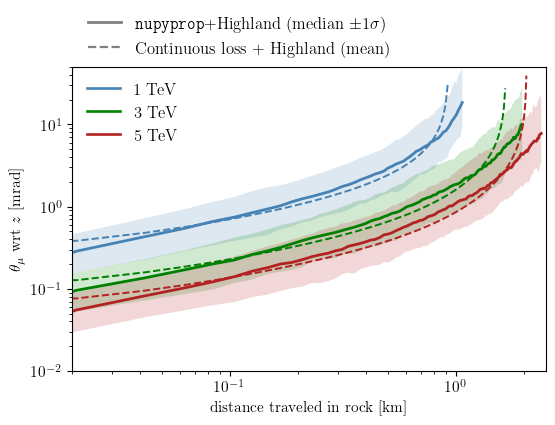

In [59]:
if RUN_VALIDATION:
    import warnings

    fig, ax = pt.std_fig(figsize=(6, 4))
    for E0t in E_VAL:
        c = VAL_COLORS[E0t]
        _, ths = trajs[E0t]
        frac = np.isfinite(ths).mean(axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            med = np.nanmedian(ths, axis=0) * 1e3
            lo = np.nanpercentile(ths, 16, axis=0) * 1e3
            hi = np.nanpercentile(ths, 84, axis=0) * 1e3
        bad = frac < 0.2
        med[bad], lo[bad], hi[bad] = np.nan, np.nan, np.nan
        ax.fill_between(Xg / KM, lo, hi, color=c, alpha=0.18, lw=0)
        ax.plot(Xg / KM, med, color=c, lw=2.0)
        prof = mb.continuous_E_profile(E0t, Xg)
        alive = prof > mb.E_MIN
        dX = np.gradient(Xg)
        s2 = np.cumsum((0.0136 * 1.15 / prof) ** 2 * dX) / mb.X0_ROCK
        an = np.where(alive, np.sqrt(2 * np.log(2) * s2) * 1e3, np.nan)
        ax.plot(Xg / KM, an, color=c, lw=1.4, ls="--")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("distance traveled in rock [km]")
    ax.set_ylabel(r"$\theta_\mu$ wrt $z$ [mrad]")
    ax.set_xlim(0.02, 2.5)
    ax.set_ylim(1e-2, 50)

    color_handles = [Line2D([], [], color=VAL_COLORS[e], lw=1.9, label=f"{e/1e3:.0f} TeV")
                     for e in E_VAL]
    style_handles = [
        Line2D([], [], color="gray", lw=2, label=r"\texttt{nupyprop}+Highland (median $\pm1\sigma$)"),
        Line2D([], [], color="gray", lw=1.6, ls="--", label="Continuous loss + Highland (mean)"),
    ]
    leg1 = ax.legend(handles=color_handles, frameon=False, fontsize=12, loc="upper left")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, frameon=False, fontsize=12, loc=(0.02, 1.01), ncol=1)

    fig.savefig("plots/muon_beam_mcs_validation.pdf", bbox_inches="tight", dpi=300)
else:
    print('Sec. 3 validation skipped (RUN_SLOW_VALIDATION = False)')

## 4. Simulate the rock-produced muon beams

`muon_beam_mc` resamples face-plane neutrino rays, assigns one rock interaction vertex per sampled ray, generates the outgoing muon, and propagates it to the detector face.  The returned weights include the parent neutrino flux, target density, cross section, and sampled rock length.

The downstream $\mu^+$ sample is DIS only.  The upstream $\mu^-$ sample contains both DIS from $\nu_\mu$ and IMD from $\nu_\mu$ and $\bar\nu_e$.

In [73]:
N_MC = 1_000_000
N_MC_IMD = 100_000

mc_p = mb.muon_beam_mc(*rays_p, "numubar", np.random.default_rng(11),
                       l_prop_cm=L_PROP, gap_cm=GAP, det_r=DET_R, n_mc=N_MC)
mc_m = mb.muon_beam_mc(*rays_m, "numu", np.random.default_rng(12),
                       l_prop_cm=L_PROP, gap_cm=GAP, det_r=DET_R, n_mc=N_MC)
imd_m = mb.muon_beam_mc(*rays_m, "numu", np.random.default_rng(13), channel="imd",
                        l_prop_cm=L_PROP, gap_cm=GAP, det_r=DET_R, n_mc=N_MC_IMD)
imd_eb = mb.muon_beam_mc(*rays_eb, "nuebar", np.random.default_rng(14), channel="imd",
                         l_prop_cm=L_PROP, gap_cm=GAP, det_r=DET_R, n_mc=N_MC_IMD)

def rates(mc):
    r = np.hypot(mc["srv_x"], mc["srv_y"])
    return (mc["w"].sum(), mc["srv_w"].sum(), mc["srv_w"][r < DET_R].sum())

for lab, mcs in [("mu+ beam (DIS, downstream)", [mc_p]),
                 ("mu- beam DIS (upstream)", [mc_m]),
                 ("mu- beam IMD nu_mu e", [imd_m]),
                 ("mu- beam IMD nuebar e", [imd_eb])]:
    p_, s_, a_ = np.sum([rates(m) for m in mcs], axis=0)
    print(f"{lab}:")
    print(f"  produced {p_:.3e}/yr | at plane {s_:.3e}/yr | in acceptance {a_:.3e}/yr")
    print(f"  per bunch crossing (in acceptance): {a_/crossings_per_year:.2f}")

acc_p = rates(mc_p)[2]
acc_m = rates(mc_m)[2] + rates(imd_m)[2] + rates(imd_eb)[2]
imd_frac = (rates(imd_m)[2] + rates(imd_eb)[2]) / acc_m
print(f"\nTOTALS in acceptance: mu+ {acc_p/crossings_per_year:.2f} /crossing | "
      f"mu- {acc_m/crossings_per_year:.2f} /crossing (IMD fraction {imd_frac:.2%})")

mu+ beam (DIS, downstream):
  produced 1.324e+13/yr | at plane 2.892e+12/yr | in acceptance 5.692e+11/yr
  per bunch crossing (in acceptance): 1.89
mu- beam DIS (upstream):
  produced 2.308e+13/yr | at plane 4.432e+12/yr | in acceptance 7.136e+11/yr
  per bunch crossing (in acceptance): 2.37
mu- beam IMD nu_mu e:
  produced 3.357e+10/yr | at plane 6.206e+09/yr | in acceptance 2.942e+09/yr
  per bunch crossing (in acceptance): 0.01
mu- beam IMD nuebar e:
  produced 9.584e+09/yr | at plane 2.155e+09/yr | in acceptance 1.021e+09/yr
  per bunch crossing (in acceptance): 0.00

TOTALS in acceptance: mu+ 1.89 /crossing | mu- 2.38 /crossing (IMD fraction 0.55%)


## 5. Spatial distribution at the detector face

These maps show all muons that reach the detector face plane.  The dashed circle is the 2 m detector radius.  The color scale is shared between the downstream and upstream panels and is normalized per bunch crossing per map bin.

The simulation only starts from parent neutrino rays inside the 6 m face-plane halo.  That is sufficient for the detector circle, but the far outer map region is not a complete prediction.

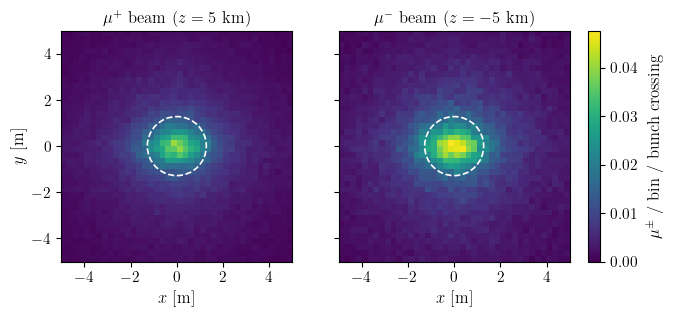

In [74]:
bins_cm = np.linspace(-500, 500, 41)

Hs = []
for mcs in ([mc_p], [mc_m, imd_m, imd_eb]):
    x = np.concatenate([m["srv_x"] for m in mcs])
    y = np.concatenate([m["srv_y"] for m in mcs])
    w = np.concatenate([m["srv_w"] for m in mcs])
    H, _, _ = np.histogram2d(x, y, bins=[bins_cm, bins_cm], weights=w)
    Hs.append(H / crossings_per_year)
vmax = max(H.max() for H in Hs)

fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
titles = [r"$\mu^+$ beam ($z = 5$~km)", r"$\mu^-$ beam ($z = -5$~km)"]
for ax, H, title in zip(axs, Hs, titles):
    im = ax.pcolormesh(bins_cm / 100, bins_cm / 100, H.T, cmap="viridis",
                       vmin=0.0, vmax=vmax, rasterized=True)
    ax.add_patch(Circle((0, 0), DET_R / 100, fill=False, color="white", lw=1.2, ls="--"))
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x$ [m]", fontsize=12)
axs[0].set_ylabel(r"$y$ [m]", fontsize=12)
cb = fig.colorbar(im, ax=axs, shrink=1, pad=0.03)
cb.set_label(r"$\mu^\pm$ / bin / bunch crossing", fontsize=12, labelpad=7)
fig.savefig("plots/muon_beam_face_maps.pdf", bbox_inches="tight", dpi=300)

central flux (r < 10 cm): mu+ 0.56 | mu- 0.67 muons/cm^2/s


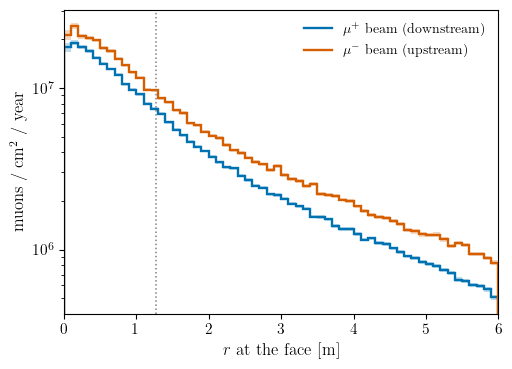

In [75]:
r_edges = np.linspace(0.0, R_SEL, 61)
r_area = np.pi * np.diff(r_edges**2)

def radial_hist(mcs):
    """Surface rate in face-plane annuli, with MC sum-of-weights uncertainty."""
    r = np.concatenate([np.hypot(m["srv_x"], m["srv_y"]) for m in mcs])
    w = np.concatenate([m["srv_w"] for m in mcs])
    h, _ = np.histogram(r, bins=r_edges, weights=w)
    h2, _ = np.histogram(r, bins=r_edges, weights=w**2)
    return h / r_area, np.sqrt(h2) / r_area

fig, ax = pt.std_fig(figsize=(5.5, 4))
for mcs, lab, c in [([mc_p], r"$\mu^+$ beam (downstream)", "#0072B2"),
                    ([mc_m, imd_m, imd_eb], r"$\mu^-$ beam (upstream)", "#D55E00")]:
    h, e = radial_hist(mcs)
    ax.stairs(h, r_edges / 100, color=c, lw=1.7, label=lab)
    ax.fill_between(np.repeat(r_edges, 2)[1:-1] / 100, np.repeat(h - e, 2),
                    np.repeat(h + e, 2), color=c, alpha=0.25, lw=0)
ax.axvline(DET_R / 100, color="gray", ls=":", lw=1.1)
ax.annotate("detector edge", xy=(DET_R / 100 * 1.03, 2e2), fontsize=8,
            color="gray", rotation=90)
ax.set_yscale("log")
ax.set_xlim(0, R_SEL / 100)
ax.set_xlabel(r"$r$ at the face [m]", fontsize=12)
ax.set_ylabel(r"muons / cm$^2$ / year", fontsize=12)
ax.legend(frameon=False, fontsize=10)
fig.savefig("plots/muon_beam_radial.pdf", bbox_inches="tight", dpi=300)

h_p, _ = radial_hist([mc_p])
h_m, _ = radial_hist([mc_m, imd_m, imd_eb])
print(f"central flux (r < {r_edges[1]:.0f} cm): "
      f"mu+ {h_p[0] / const.s_in_year:.2f} | mu- {h_m[0] / const.s_in_year:.2f} muons/cm^2/s")

## 6. Energy spectra

For each beam, the plot shows the generated muons at production, the subset that reaches the face plane, and the subset inside the 2 m detector radius.  Colors indicate the stage and line style indicates the beam charge.  The upstream $\mu^-$ total includes its small IMD contribution.

Propagation removes soft muons that range out in rock.  The detector-radius cut further favors high-energy muons because they are more collinear and scatter less.

In [148]:
mc_m['w'].sum()

np.float64(23077960485424.355)

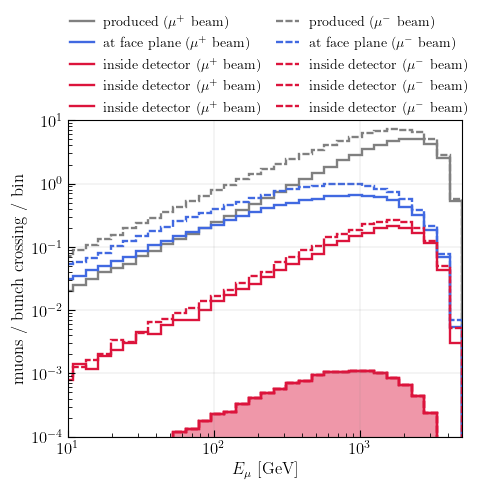

In [150]:
E_edges = np.geomspace(1.0, 5e3, 44)

def hist_pc(E, w):
    h, _ = np.histogram(E, bins=E_edges, weights=w)
    return h / crossings_per_year

def accepted_arrays(m):
    r = np.hypot(m["srv_x"], m["srv_y"])
    sel = r < DET_R
    return m["srv_E"][sel], m["srv_w"][sel]

stage_configs = [
    (lambda m: (m["E_mu"], m["w"]), "grey", "produced"),
    (lambda m: (m["srv_E"], m["srv_w"]), "royalblue", "at face plane"),
    (accepted_arrays, "crimson", "inside detector"),
]
beam_configs = [
    ([mc_p], r"$\mu^+$ beam", "-"),
    ([mc_m, imd_m, imd_eb], r"$\mu^-$ beam", (0, (3, 1))),
]

fig, ax = plt.subplots(figsize=(5, 5))
for allmc, beam_label, ls in beam_configs:
    for selector, color, stage in stage_configs:
        h = np.sum([hist_pc(*selector(m)) for m in allmc], axis=0)
        ax.stairs(h, E_edges, color=color, lw=1.7, ls=ls,
                  label=f"{stage} ({beam_label})")
        if stage == "inside detector":
            h = np.sum([hist_pc(*selector(m)) for m in [imd_m, imd_eb]], axis=0)
            ax.stairs(h, E_edges, color=color, lw=1.7, ls=ls,
                  label=f"{stage} ({beam_label})")
            ax.stairs(h, E_edges, color=color, lw=1.7, ls=ls,
                              label=f"{stage} ({beam_label})")
            ax.fill_between(np.repeat(E_edges, 2)[1:-1], np.repeat(h, 2), color=color,
                            alpha=0.25, lw=0)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 5e3)
ax.set_ylim(1e-4, 10)
ax.set_xlabel(r"$E_\mu$ [GeV]", fontsize=12)
ax.set_ylabel(r"muons / bunch crossing / bin", fontsize=12)
ax.legend(frameon=False, fontsize=10, loc=(-0.01, 1.0), ncol=2,
          handlelength=1.7, handletextpad=0.7, columnspacing=1)
ax.grid(which="major", ls="-", lw=0.25, color="gray", alpha=0.5)
ax.tick_params(which="minor", length=3, direction="in")
ax.tick_params(which="major", length=5, direction="in")
ax.tick_params(labelsize=12)

fig.tight_layout()
fig.savefig("plots/muon_beam_spectra.pdf", bbox_inches="tight", dpi=300)

## 7. Production depth of accepted muons

This plot uses the accepted muons and histograms their production distance from the detector face.  The shape is driven by range: near the face many energies survive, while deep in the 2.5 km source window only the highest-energy muons can arrive.

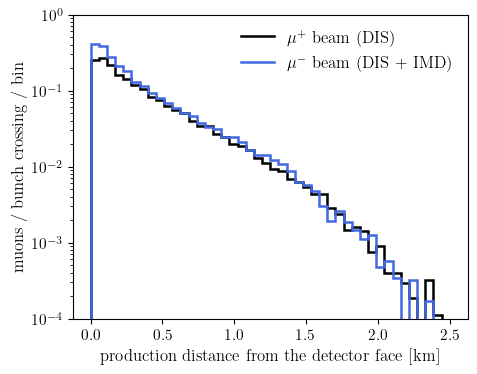

In [89]:
L_edges = np.linspace(0.0, 2.5, 45)

fig, ax = pt.std_fig(figsize=(5, 4))
for mcs, c, lab in [([mc_p], "black", r"$\mu^+$ beam (DIS)"),
                    ([mc_m, imd_m, imd_eb], "royalblue", r"$\mu^-$ beam (DIS + IMD)")]:
    d = np.concatenate([m["srv_dface"][np.hypot(m["srv_x"], m["srv_y"]) < DET_R]
                        for m in mcs])
    w = np.concatenate([m["srv_w"][np.hypot(m["srv_x"], m["srv_y"]) < DET_R]
                        for m in mcs])
    h, _ = np.histogram(d / 1e5, bins=L_edges, weights=w)
    ax.stairs(h / crossings_per_year, L_edges, color=c, lw=1.8, label=lab)
ax.set_xlabel("production distance from the detector face [km]", fontsize=12)
ax.set_ylabel("muons / bunch crossing / bin", fontsize=12)
ax.legend(frameon=False, fontsize=12)
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.0)
fig.savefig("plots/muon_beam_production_points.pdf", bbox_inches="tight", dpi=300)

## 8. Arrival times at the detector face

The plotted time is
$$\Delta t = t_{\rm arrival} - L_{\rm det}/c,$$
relative to a light signal emitted from the IP when the bunch centroid crosses it.

For primary neutrinos, the code combines the muon-decay time relative to the bunch crossing with the neutrino path length to the detector face.  For secondary muons, `muon_beam_mc` now keeps the index of the parent face-plane neutrino ray for every sampled muon.  The timing calculation uses that same parent delay and then adds `mb.secondary_muon_delay_ns`, which contains two high-energy approximations: a muon-mass delay proportional to $m_\mu^2 L/(2E_{\rm prod}E_{\rm face})$ and an angular path-length delay proportional to $\theta_{\rm face}^2L/4$.

The secondary-$\nu_\tau$ timing shown for comparison uses the charm-chain sampler from `nutau_secondary.py`; its parent neutrino delay is sampled from the same halo flux with a charm-cross-section weight.

In [90]:
from mint import xsecs
import nutau_secondary as nts

C_NS = mb.C_CM_PER_NS

def nu_face_delays(s, sign=+1, r_sel=DET_R, E_min=15.0):
    """Parent-neutrino face delays in the same order as det.face_rays."""
    (ox, oy, oz), (vx, vy, vz) = dt.sim_rays(s)
    E = np.asarray(s.pnu["E"])
    w = s.weights.flatten() * injections_per_year
    ozs, vzs = (oz, vz) if sign > 0 else (-oz, -vz)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = (DIST - ozs) / vzs
    rx, ry = ox + t * vx, oy + t * vy
    m = (t > 0) & (rx**2 + ry**2 < r_sel**2) & (E > E_min)
    face = np.array([0.0, 0.0, sign * DIST])
    pos = np.column_stack([np.asarray(s.pos["x"]), np.asarray(s.pos["y"]),
                           np.asarray(s.pos["z"])])
    dist_to_face = np.linalg.norm(pos[m] - face, axis=1)
    delay = (np.asarray(s.mutimes_to_bunchx)[m] * 1e9
             + dist_to_face / C_NS - DIST / C_NS)
    return delay, w[m], E[m], m

def hist_mc_err(x, bins, w=None):
    """Weighted histogram and sqrt(sum w^2) MC uncertainty."""
    if w is None:
        w = np.ones_like(x, dtype=float)
    h, _ = np.histogram(x, bins=bins, weights=w)
    h2, _ = np.histogram(x, bins=bins, weights=w**2)
    return h, np.sqrt(h2)

In [91]:
def target_column_for_ray(s, det, sign=+1):
    """Nucleon column traversed inside the gas volume and tungsten targets."""
    origin, direction = dt.sim_rays(s)
    _, gas_chord = det.volume(sign=sign).intersect(origin, direction)
    column = det.gas.N * gas_chord

    for z0, thick, mat in det.targets:
        slab = dt.CylinderVolume(
            mat,
            radius=det.radius,
            length=thick,
            center=(0.0, 0.0, sign * (det.dist + z0 + 0.5 * thick)),
            name="target",
        )
        _, slab_chord = slab.intersect(origin, direction)
        column += mat.N * slab_chord

    return column


def nu_interaction_delays(s, det, sign=+1, E_min=15.0, nuflavor=None):
    """Arrival delays for primary-neutrino interactions inside the detector."""
    (ox, oy, oz), (vx, vy, vz) = dt.sim_rays(s)
    E = np.asarray(s.pnu["E"])
    w_flux = s.weights.flatten() * injections_per_year

    ozs, vzs = (oz, vz) if sign > 0 else (-oz, -vz)
    with np.errstate(divide="ignore", invalid="ignore"):
        t_face = (det.dist - ozs) / vzs

    rx, ry = ox + t_face * vx, oy + t_face * vy
    m = (t_face > 0) & (rx**2 + ry**2 < det.radius**2) & (E > E_min)

    det_face = np.array([0.0, 0.0, sign * det.dist])
    pos = np.column_stack([
        np.asarray(s.pos["x"]),
        np.asarray(s.pos["y"]),
        np.asarray(s.pos["z"]),
    ])
    dist_to_face = np.linalg.norm(pos[m] - det_face, axis=1)

    delay = (
        np.asarray(s.mutimes_to_bunchx)[m] * 1e9
        + dist_to_face / C_NS
        - det.dist / C_NS
    )

    flavor = nuflavor or s.nuflavor
    sigma = np.clip(xsecs.total_xsecs[flavor](E[m]), 0.0, None)
    column = target_column_for_ray(s, det, sign=sign)[m]
    p_int = -np.expm1(-sigma * column)

    return delay, w_flux[m] * p_int, E[m], m


d_nu_int, w_nu_int_t, E_nu_int, _ = nu_interaction_delays(sim, det, +1)
d_nu_halo, w_nu_halo_t, E_nu_halo_t, _ = nu_face_delays(sim, +1, r_sel=R_SEL)

rng_t = np.random.default_rng(3)
r_acc = np.hypot(mc_p["srv_x"], mc_p["srv_y"]) < DET_R
Emu_f, Emu_p = mc_p["srv_E"][r_acc], mc_p["srv_E_prod"][r_acc]
dface, th_f = mc_p["srv_dface"][r_acc], mc_p["srv_theta"][r_acc]
w_mu_t = mc_p["srv_w"][r_acc]
parent = mc_p["srv_parent_index"][r_acc]
d_mu = d_nu_halo[parent] + mb.secondary_muon_delay_ns(Emu_p, Emu_f, dface, th_f)

edges_t = np.geomspace(20.0, 5000.0, 40)
E_r, w_r, *_ = rays_p
W_t, _ = np.histogram(E_r, bins=edges_t, weights=w_r)
Ec_t = np.sqrt(edges_t[:-1] * edges_t[1:])
E1, th1, E2, th2 = nts.sample_nutau_chains(120_000, Ec_t, W_t, "numubar", rng=4)
s_prod = rng_t.uniform(det.rock_start, DIST - GAP, 120_000)
L_rem = DIST - s_prod
tau_sel = np.concatenate([(th1 * L_rem < DET_R), (th2 * L_rem < DET_R)])
th_all = np.concatenate([th1, th2])
L_all = np.concatenate([L_rem, L_rem])
p_tau_par = w_nu_halo_t * nts.sigma_charm_cc(E_nu_halo_t, "numubar")
parent2 = rng_t.choice(d_nu_halo.size, size=tau_sel.sum(), p=p_tau_par / p_tau_par.sum())
d_tau = d_nu_halo[parent2] + 0.5 * th_all[tau_sel] ** 2 * L_all[tau_sel] / C_NS
n_chains = (rock.N * (DIST - GAP - det.rock_start)
            * (nts.F_DS * nts.BR_DS_TAUNU + nts.F_DPM * nts.BR_DPM_TAUNU)
            * float(np.sum(W_t * nts.sigma_charm_cc(Ec_t, "numubar"))))
w_tau_t = np.full(tau_sel.sum(), n_chains / 120_000)

tb = np.linspace(-0.05, 0.2, 50)
centers = np.sqrt(tb[:-1] * tb[1:])

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_29776/790446799.py:86: RuntimeWarning: invalid value encountered in sqrt
  centers = np.sqrt(tb[:-1] * tb[1:])


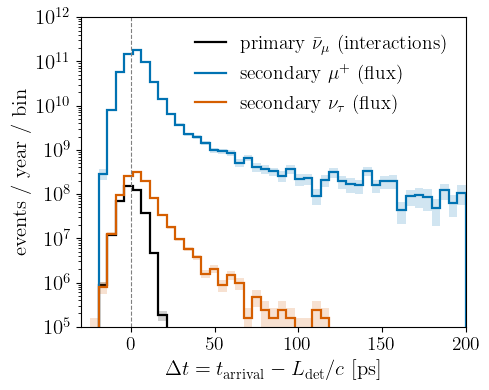

In [92]:
fig, ax = plt.subplots(figsize=(5, 4))
for d_, w_, lab, c in [(d_nu_int, w_nu_int_t, r"primary $\bar\nu_\mu$ (interactions)", "black"),
                       (d_mu, w_mu_t, r"secondary $\mu^+$ (flux)", "#0072B2"),
                       (d_tau, w_tau_t, r"secondary $\nu_\tau$ (flux)", "#D55E00")]:
    h, e = hist_mc_err(d_, tb, w_)
    ax.stairs(h, tb * 1e3, color=c, lw=1.6, label=lab)
    lo = np.where(h > 0, h - np.minimum(e, 0.999 * h), np.nan)
    hi = np.where(h > 0, h + e, np.nan)
    ax.fill_between(tb * 1e3, np.r_[lo, lo[-1]], np.r_[hi, hi[-1]],
                    step="post", color=c, alpha=0.18, linewidth=0)

ax.set_yscale("log")
ax.set_ylim(1e5, 1e12)
ax.set_xlim(-30, 0.2 * 1e3)
ax.set_xticks(np.linspace(0, 200, 5))
ax.axvline(0.0, color="gray", ls="--", lw=0.8)
ax.tick_params(axis="y", labelsize=15)
ax.tick_params(axis="x", labelsize=14)
ax.set_xlabel(r"$\Delta t = t_{\rm arrival} - L_{\rm det}/c$ [ps]", fontsize=15)
ax.set_ylabel("events / year / bin", fontsize=15)
ax.legend(frameon=False, fontsize=14, loc="upper right", handlelength=1.6, handletextpad=0.7)
plt.tight_layout()
fig.savefig("plots/muon_beam_arrival_times.pdf", bbox_inches="tight", dpi=300)

## 9. Beam-dynamics comparison

This repeats the same downstream and upstream DIS pipeline with `beam_dynamics=False`.  In that configuration the stored muon decays follow the ideal closed orbit with nominal momentum, no transverse emittance, no angular divergence, no momentum spread, and no bunch length.  The comparison isolates how the accelerator beam distribution broadens the neutrino and tertiary-muon observables.

In [16]:
ring_nb, sims_nb, _ = mint.examples.both_beams(
    flavors=("numubar", "numu", "nuebar"), beam_dynamics=False)
rays_p_nb = det.face_rays(sims_nb["numubar"], sign=+1, r_sel=R_SEL, E_min=15.0,
                          exposure=injections_per_year)
rays_m_nb = det.face_rays(sims_nb["numu"], sign=-1, r_sel=R_SEL, E_min=15.0,
                          exposure=injections_per_year)
mc_p_nb = mb.muon_beam_mc(*rays_p_nb, "numubar", np.random.default_rng(21),
                          l_prop_cm=L_PROP, gap_cm=GAP, det_r=DET_R, n_mc=N_MC)
mc_m_nb = mb.muon_beam_mc(*rays_m_nb, "numu", np.random.default_rng(22),
                          l_prop_cm=L_PROP, gap_cm=GAP, det_r=DET_R, n_mc=N_MC)

for lab, mc0, mc1 in [("mu+ beam", mc_p, mc_p_nb), ("mu- beam", mc_m, mc_m_nb)]:
    a0 = mc0["srv_w"][np.hypot(mc0["srv_x"], mc0["srv_y"]) < DET_R].sum()
    a1 = mc1["srv_w"][np.hypot(mc1["srv_x"], mc1["srv_y"]) < DET_R].sum()
    print(f"{lab} (DIS): {a0/crossings_per_year:.2f} -> {a1/crossings_per_year:.2f} "
          f"muons/crossing in acceptance (beam dynamics on -> off, "
          f"{a1/a0 - 1:+.1%})")
print("(IMD channels omitted here: sub-percent of the mu- rate)")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


mu+ beam (DIS): 1.88 -> 2.80 muons/crossing in acceptance (beam dynamics on -> off, +49.3%)
mu- beam (DIS): 2.30 -> 3.45 muons/crossing in acceptance (beam dynamics on -> off, +49.7%)
(IMD channels omitted here: sub-percent of the mu- rate)


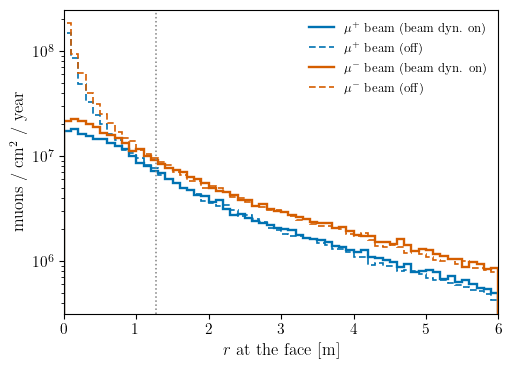

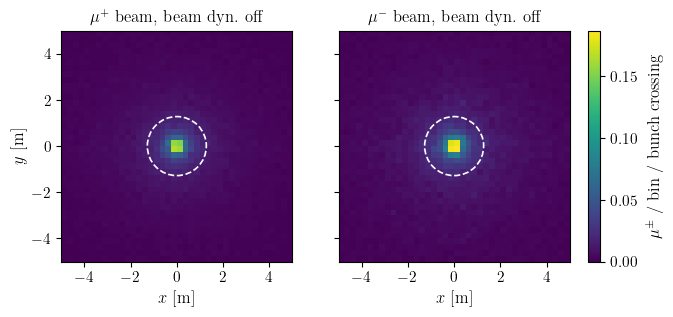

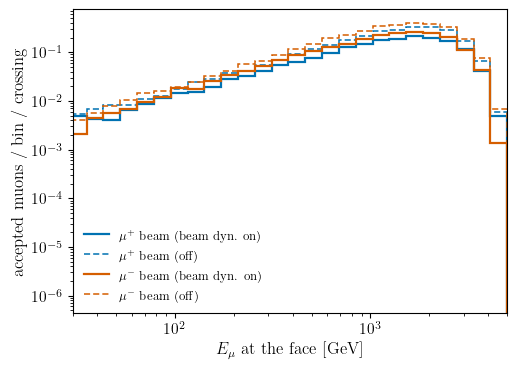

In [17]:
fig, ax = pt.std_fig(figsize=(5.5, 4))
for mc_on, mc_off, lab, c in [
        (mc_p, mc_p_nb, r"$\mu^+$ beam", "#0072B2"),
        (mc_m, mc_m_nb, r"$\mu^-$ beam", "#D55E00")]:
    h_on, _ = radial_hist([mc_on])
    h_off, _ = radial_hist([mc_off])
    ax.stairs(h_on, r_edges / 100, color=c, lw=1.7, label=lab + " (beam dyn. on)")
    ax.stairs(h_off, r_edges / 100, color=c, lw=1.2, ls=(0, (4, 2)),
              label=lab + " (off)")
ax.axvline(DET_R / 100, color="gray", ls=":", lw=1.1)
ax.set_yscale("log")
ax.set_xlim(0, R_SEL / 100)
ax.set_xlabel(r"$r$ at the face [m]", fontsize=12)
ax.set_ylabel(r"muons / cm$^2$ / year", fontsize=12)
ax.legend(frameon=False, fontsize=9)
fig.savefig("plots/muon_beam_radial_nobd.pdf", bbox_inches="tight", dpi=300)

Hs_nb = []
for mcs in ([mc_p_nb], [mc_m_nb]):
    x = np.concatenate([m["srv_x"] for m in mcs])
    y = np.concatenate([m["srv_y"] for m in mcs])
    w = np.concatenate([m["srv_w"] for m in mcs])
    H, _, _ = np.histogram2d(x, y, bins=[bins_cm, bins_cm], weights=w)
    Hs_nb.append(H / crossings_per_year)
vmax_nb = max(H.max() for H in Hs_nb)
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax_, H, title in zip(axs, Hs_nb,
                         [r"$\mu^+$ beam, beam dyn. off", r"$\mu^-$ beam, beam dyn. off"]):
    im = ax_.pcolormesh(bins_cm / 100, bins_cm / 100, H.T, cmap="viridis",
                        vmin=0.0, vmax=vmax_nb, rasterized=True)
    ax_.add_patch(Circle((0, 0), DET_R / 100, fill=False, color="white", lw=1.2, ls="--"))
    ax_.set_title(title, fontsize=12)
    ax_.set_aspect("equal")
    ax_.set_xlabel(r"$x$ [m]", fontsize=12)
axs[0].set_ylabel(r"$y$ [m]", fontsize=12)
cb = fig.colorbar(im, ax=axs, shrink=1, pad=0.03)
cb.set_label(r"$\mu^\pm$ / bin / bunch crossing", fontsize=12, labelpad=7)
fig.savefig("plots/muon_beam_face_maps_nobd.pdf", bbox_inches="tight", dpi=300)

fig, ax = pt.std_fig(figsize=(5.5, 4))
for mc_on, mc_off, lab, c in [
        (mc_p, mc_p_nb, r"$\mu^+$ beam", "#0072B2"),
        (mc_m, mc_m_nb, r"$\mu^-$ beam", "#D55E00")]:
    for mc_, ls, tag in [(mc_on, "-", " (beam dyn. on)"), (mc_off, (0, (4, 2)), " (off)")]:
        r_ = np.hypot(mc_["srv_x"], mc_["srv_y"])
        h = np.histogram(mc_["srv_E"][r_ < DET_R], bins=E_edges,
                         weights=mc_["srv_w"][r_ < DET_R])[0] / crossings_per_year
        ax.stairs(h, E_edges, color=c, lw=1.6 if ls == "-" else 1.1, ls=ls,
                  label=lab + tag)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(30, 5e3)
ax.set_xlabel(r"$E_\mu$ at the face [GeV]", fontsize=12)
ax.set_ylabel(r"accepted muons / bin / crossing", fontsize=12)
ax.legend(frameon=False, fontsize=9)
fig.savefig("plots/muon_beam_spectra_nobd.pdf", bbox_inches="tight", dpi=300)

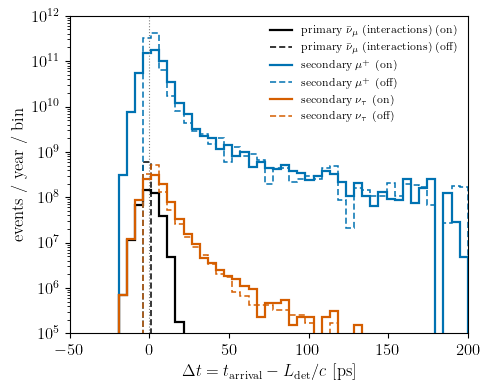

In [18]:
d_nu_int_nb, w_nu_int_nb, _, _ = nu_interaction_delays(sims_nb["numubar"], det, +1)
d_nu_nb, w_nu_nb, E_nu_nb, _ = nu_face_delays(sims_nb["numubar"], +1, r_sel=R_SEL)

rng_nb = np.random.default_rng(23)
r_acc_nb = np.hypot(mc_p_nb["srv_x"], mc_p_nb["srv_y"]) < DET_R
Emu_f_nb, Emu_p_nb = mc_p_nb["srv_E"][r_acc_nb], mc_p_nb["srv_E_prod"][r_acc_nb]
dface_nb, th_f_nb = mc_p_nb["srv_dface"][r_acc_nb], mc_p_nb["srv_theta"][r_acc_nb]
w_mu_nb = mc_p_nb["srv_w"][r_acc_nb]
parent_nb = mc_p_nb["srv_parent_index"][r_acc_nb]
d_mu_nb = d_nu_nb[parent_nb] + mb.secondary_muon_delay_ns(Emu_p_nb, Emu_f_nb, dface_nb, th_f_nb)

E_r_nb, w_r_nb = rays_p_nb[0], rays_p_nb[1]
W_t_nb, _ = np.histogram(E_r_nb, bins=edges_t, weights=w_r_nb)
E1n, th1n, E2n, th2n = nts.sample_nutau_chains(120_000, Ec_t, W_t_nb, "numubar", rng=24)
s_prod_nb = rng_nb.uniform(det.rock_start, DIST - GAP, 120_000)
L_rem_nb = DIST - s_prod_nb
tau_sel_nb = np.concatenate([(th1n * L_rem_nb < DET_R), (th2n * L_rem_nb < DET_R)])
th_all_nb = np.concatenate([th1n, th2n])
L_all_nb = np.concatenate([L_rem_nb, L_rem_nb])
p_par2 = w_nu_nb * nts.sigma_charm_cc(E_nu_nb, "numubar")
par2 = rng_nb.choice(d_nu_nb.size, size=tau_sel_nb.sum(), p=p_par2 / p_par2.sum())
d_tau_nb = d_nu_nb[par2] + 0.5 * th_all_nb[tau_sel_nb] ** 2 * L_all_nb[tau_sel_nb] / C_NS
n_chains_nb = (rock.N * (DIST - GAP - det.rock_start)
               * (nts.F_DS * nts.BR_DS_TAUNU + nts.F_DPM * nts.BR_DPM_TAUNU)
               * float(np.sum(W_t_nb * nts.sigma_charm_cc(Ec_t, "numubar"))))
w_tau_nb = np.full(tau_sel_nb.sum(), n_chains_nb / 120_000)

fig, ax = plt.subplots(figsize=(5, 4))
for (d_on, w_on, d_off, w_off, lab, c) in [
        (d_nu_int, w_nu_int_t, d_nu_int_nb, w_nu_int_nb,
         r"primary $\bar\nu_\mu$ (interactions)", "black"),
        (d_mu, w_mu_t, d_mu_nb, w_mu_nb, r"secondary $\mu^+$", "#0072B2"),
        (d_tau, w_tau_t, d_tau_nb, w_tau_nb, r"secondary $\nu_\tau$", "#D55E00")]:
    h_on, _ = hist_mc_err(d_on, tb, w_on)
    h_off, _ = hist_mc_err(d_off, tb, w_off)
    ax.stairs(h_on, tb * 1e3, color=c, lw=1.6, label=lab + " (on)")
    ax.stairs(h_off, tb * 1e3, color=c, lw=1.1, ls=(0, (4, 2)), label=lab + " (off)")
ax.set_yscale("log")
ax.set_ylim(1e5, 1e12)
ax.set_xlim(-0.05 * 1e3, 0.2 * 1e3)
ax.set_xticks(np.linspace(-50, 200, 6))
ax.axvline(0.0, color="gray", ls=":", lw=0.8)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel(r"$\Delta t = t_{\rm arrival} - L_{\rm det}/c$ [ps]", fontsize=12)
ax.set_ylabel("events / year / bin", fontsize=12)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig("plots/muon_beam_arrival_times_nobd.pdf", bbox_inches="tight", dpi=300)

## 10. Michel electrons from muon decays in flight

A small fraction of the accepted tertiary muons decay between the rock wall and the back of the detector.  This section samples the resulting Michel electrons and compares a fully longitudinally polarized muon beam with an unpolarized one.

For an ultrarelativistic muon, the lab-frame electron energy fraction $y=E_e/E_\mu$ is sampled from
$$f(y)=g_0(y)-P'g_1(y),$$
where $P'=1$ corresponds to the helicity expected for both the downstream $\mu^+$ beam and the upstream $\mu^-$ beam after accounting for CP.  The polarized spectrum is harder than the unpolarized spectrum, especially near the endpoint.

In [133]:
L_DEC

8550.0

$\mathcal{P}_{\mu^+}=+1$: 1.973e+07 decays/yr in the 20 m, <E_mu(decaying)> = 396 GeV, <E_e> = 158 GeV
$\mathcal{P}_{\mu^+}=0$: 1.973e+07 decays/yr in the 20 m, <E_mu(decaying)> = 396 GeV, <E_e> = 139 GeV
  P'=1: sampled <y> = 0.4000, analytic 0.4000
  P'=0: sampled <y> = 0.3498, analytic 0.3500


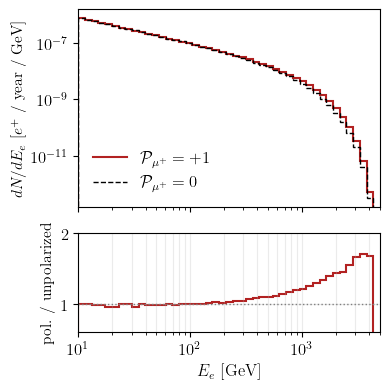

In [143]:
CTAU_MU = const.c_LIGHT * const.tau0_mu
L_DEC = GAP + det.length
rng_mic = np.random.default_rng(31)
N_REP = 40


def sample_michel_y(n, P_eff, rng):
    """Sample y = E_e/E_mu from the boosted Michel spectrum."""
    yg = np.linspace(0.0, 1.0, 4001)
    f = ((5/3 - 3*yg**2 + 4*yg**3/3)
         - P_eff * (1/3 - 3*yg**2 + 8*yg**3/3))
    cdf = np.concatenate([[0.0], np.cumsum(0.5*(f[1:] + f[:-1]) * np.diff(yg))])
    cdf /= cdf[-1]
    return np.interp(rng.uniform(0.0, 1.0, n), cdf, yg)


def michel_spectrum(mc, P_eff):
    """Michel-electron energies and weights from accepted muon decays."""
    acc = np.hypot(mc["srv_x"], mc["srv_y"]) < DET_R
    E_mu, w_mu = mc["srv_E"][acc], mc["srv_w"][acc]
    p_dec = -np.expm1(-L_DEC * const.m_mu / (E_mu * CTAU_MU))
    y = sample_michel_y(E_mu.size * N_REP, P_eff, rng_mic)
    E_e = np.repeat(E_mu, N_REP) * y
    w_e = np.repeat(w_mu * p_dec, N_REP) / N_REP
    return E_e, w_e, float(np.sum(w_mu * p_dec)), np.average(E_mu, weights=w_mu*p_dec)


E_edges = np.geomspace(10.0, 5e3, 46)
dE = np.diff(E_edges)

fig, (axL, axR) = plt.subplots(2, 1, figsize=(4, 4), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
spec = {}
for P_eff, lab, ls, lw in [(1.0, r"$\mathcal{P}_{\mu^+}=+1$", "-", 1.5),
                           (0.0, r"$\mathcal{P}_{\mu^+}=0$", "--", 1)]:
    E_e, w_e, n_dec, Emu_dec = michel_spectrum(mc_p, P_eff)
    h = np.histogram(E_e, bins=E_edges, weights=w_e)[0] / dE/crossings_per_year
    spec[P_eff] = h
    col = "firebrick" if P_eff == 1.0 else "black"
    axL.stairs(h, E_edges, color=col, lw=lw, ls=ls, label=lab)
    print(f"{lab:16s}: {n_dec:.3e} decays/yr in the 20 m, "
          f"<E_mu(decaying)> = {Emu_dec:.0f} GeV, "
          f"<E_e> = {np.average(E_e, weights=w_e):.0f} GeV")

axL.set_yscale("log")
axL.set_xlim(10, 5e3)
axL.set_ylabel(r"$dN/dE_e$ [$e^+$ / year / GeV]", fontsize=11)
axL.legend(frameon=False, fontsize=12, loc="lower left")
# axL.set_title(r"Michel $e^+$ from $\mu^+$ decays in flight, rock wall $\to$ detector back",
#               fontsize=12)
axL.tick_params(labelsize=12)

ratio = np.where(spec[0.0] > 0, spec[1.0] / np.maximum(spec[0.0], 1e-300), np.nan)
axR.stairs(ratio, E_edges, color="firebrick", lw=1.5)
axR.axhline(1.0, color="gray", ls=":", lw=1.0)
axR.set_xscale("log")
axR.set_ylim(0.6, 2)
axR.set_xlabel(r"$E_e$ [GeV]", fontsize=12)
axR.set_ylabel("pol. / unpolarized", fontsize=11)
axR.tick_params(labelsize=12)
axR.grid(True, which="both", alpha=0.25)

fig.tight_layout()
fig.savefig("plots/muon_beam_michel_spectrum.pdf", bbox_inches="tight", dpi=300)

yv = np.linspace(0, 1, 300)
for P_eff in (1.0, 0.0):
    s = sample_michel_y(400_000, P_eff, rng_mic)
    ana = (5/3 - 3*yv**2 + 4*yv**3/3) - P_eff*(1/3 - 3*yv**2 + 8*yv**3/3)
    print(f"  P'={P_eff:.0f}: sampled <y> = {s.mean():.4f}, analytic "
          f"{np.trapezoid(yv*ana, yv):.4f}")


## 11. Practical notes

- The 10 m air gap is modeled as a drift after the rock: no energy loss or scattering, but the final muon angle continues to move the face-plane position.
- Neutrinos below 15 GeV are not selected.  The DIS tables start at 50 GeV, while IMD turns on at 10.9 GeV; below 50 GeV only IMD contributes in this notebook.
- `muon_beam_mc` reports both all generated muons and the subset that survives to the face plane.  Detector acceptance is applied later with `sqrt(srv_x^2+srv_y^2) < DET_R`.
- The tertiary muon rate is orders of magnitude larger than the neutrino interaction rate in the compact detector, so it is a trigger and occupancy driver as well as a potential beam monitor.
- Neglected direct muon sources include soft shower muons from $\pi/K$ decays and semileptonic charm decays in $\nu_e/\bar\nu_e$ CC interactions.  They are expected to be subdominant for the hard through-going muon beam studied here.